In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [2]:
DATASET_PATH = "dataset"
print("Dataset var mı?", os.path.exists(DATASET_PATH))

Dataset var mı? True


In [3]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU bulundu:")
    for gpu in gpus:
        print(gpu)

    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth aktif edildi.")
    except RuntimeError as e:
        print(e)

else:
    print("GPU bulunamadı. Model CPU ile çalışacak.")

TensorFlow version: 2.16.2
GPU bulundu:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU memory growth aktif edildi.


In [4]:
devices = tf.config.list_physical_devices()
print("Cihazlar:", devices)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Harika! {len(gpu_devices)} adet GPU aktif.")
else:
    print("GPU bulunamadı, kurulumu kontrol etmelisin.")

Cihazlar: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Harika! 1 adet GPU aktif.


In [5]:
for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    
    if os.path.isdir(folder_path):
        print(folder)

Real
StyleGAN
FaceShifter
FaceSwap
Midjourney
DALL-E
DeepFaceLab
NeuralTextures
Face2Face
Stable Diffusion


In [6]:
image_extensions = [".jpg", ".jpeg", ".png", ".webp"]

data = []

for img_path in Path(DATASET_PATH).rglob("*"):
    if img_path.suffix.lower() in image_extensions:
        label = img_path.parent.name
        
        data.append({
            "filepath": str(img_path),
            "label": label
        })

df = pd.DataFrame(data)

print(df.head())
print(df["label"].value_counts())
print("Toplam görsel sayısı:", len(df))
print("Toplam class sayısı:", df["label"].nunique())

                     filepath label
0  dataset/Real/REAL_0242.jpg  Real
1  dataset/Real/REAL_2455.jpg  Real
2  dataset/Real/REAL_3993.jpg  Real
3  dataset/Real/REAL_4024.jpg  Real
4  dataset/Real/REAL_4742.jpg  Real
label
Real                5890
Stable Diffusion    2098
DALL-E              2000
DeepFaceLab         1606
FaceSwap            1600
StyleGAN            1000
FaceShifter         1000
NeuralTextures      1000
Face2Face           1000
Midjourney           930
Name: count, dtype: int64
Toplam görsel sayısı: 18124
Toplam class sayısı: 10


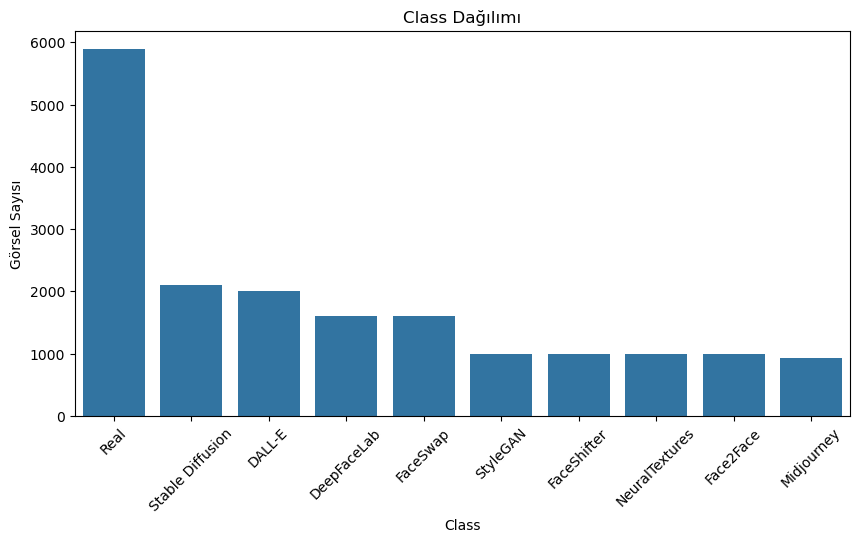

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Dağılımı")
plt.xlabel("Class")
plt.ylabel("Görsel Sayısı")
plt.show()

In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 12686
Validation: 2719
Test: 2719


In [17]:
IMG_SIZE = 128
BATCH_SIZE = 64

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,        
    zoom_range=0.2,
    horizontal_flip=True,
)
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [19]:
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(train_gen.class_indices)

Found 12686 validated image filenames belonging to 10 classes.
Found 2719 validated image filenames belonging to 10 classes.
Found 2719 validated image filenames belonging to 10 classes.
{'DALL-E': 0, 'DeepFaceLab': 1, 'Face2Face': 2, 'FaceShifter': 3, 'FaceSwap': 4, 'Midjourney': 5, 'NeuralTextures': 6, 'Real': 7, 'Stable Diffusion': 8, 'StyleGAN': 9}


In [20]:
num_classes = len(train_gen.class_indices)
print("Class sayısı:", num_classes)

Class sayısı: 10


In [21]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001),input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation="relu", padding="same",kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Conv2D(128, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Conv2D(256, (3,3), activation="relu", padding="same", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    
    Dense(512, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(256, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

/opt/anaconda3/envs/whomadeit_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "deepfake_multiclass_cnn_2_egitim.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks,
)

Epoch 1/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.2854 - loss: 6.2269 - val_accuracy: 0.1159 - val_loss: 29.0548 - learning_rate: 0.0010
Epoch 2/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.3050 - loss: 7.2726 - val_accuracy: 0.1670 - val_loss: 6.0755 - learning_rate: 0.0010
Epoch 3/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.3956 - loss: 4.5582 - val_accuracy: 0.4104 - val_loss: 5.0877 - learning_rate: 0.0010
Epoch 4/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.4730 - loss: 3.0185 - val_accuracy: 0.5362 - val_loss: 2.4171 - learning_rate: 0.0010
Epoch 5/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.5321 - loss: 2.3578 - val_accuracy: 0.5182 - val_loss: 2.1980 - learning_rate: 0.0010
Epoch 6/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - accuracy: 0.5734 - loss: 1.9621 - val_accuracy: 0.4991 - val_loss: 2.3082 - learning_rate: 0.0010
Epoch 7/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.6106 - loss: 1

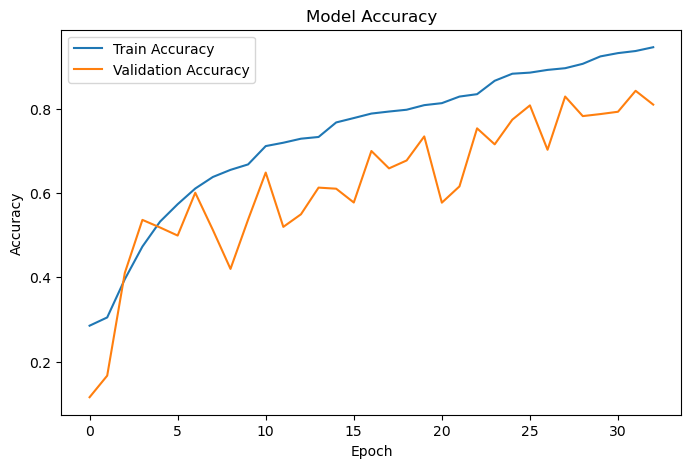

In [23]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

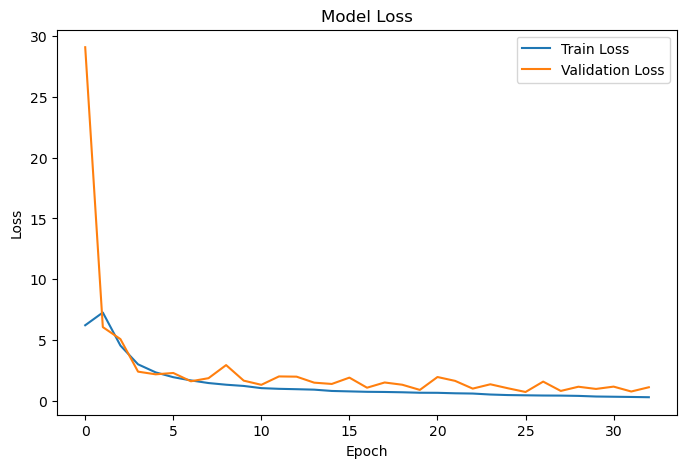

In [24]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [25]:
test_loss, test_acc = model.evaluate(test_gen)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.7981 - loss: 0.7461
Test Accuracy: 0.7980875372886658
Test Loss: 0.7461382150650024


43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step


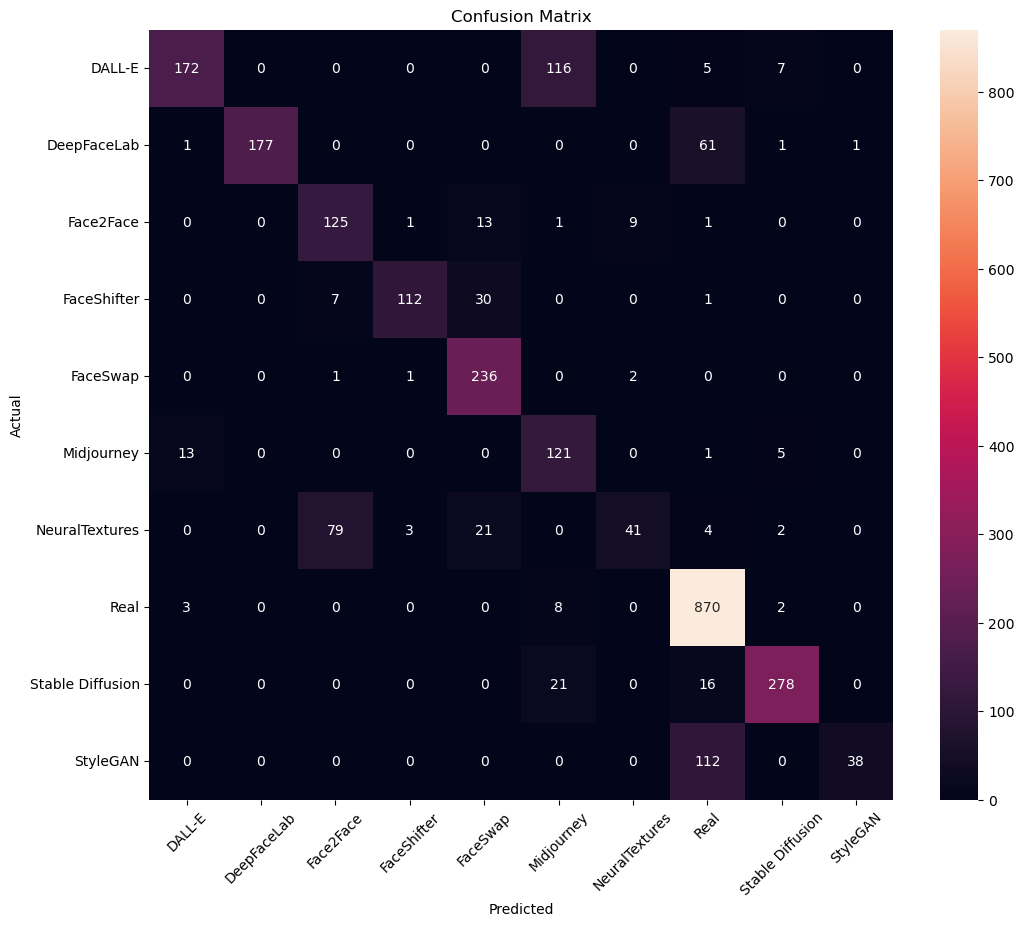

                  precision    recall  f1-score   support

          DALL-E       0.91      0.57      0.70       300
     DeepFaceLab       1.00      0.73      0.85       241
       Face2Face       0.59      0.83      0.69       150
     FaceShifter       0.96      0.75      0.84       150
        FaceSwap       0.79      0.98      0.87       240
      Midjourney       0.45      0.86      0.59       140
  NeuralTextures       0.79      0.27      0.41       150
            Real       0.81      0.99      0.89       883
Stable Diffusion       0.94      0.88      0.91       315
        StyleGAN       0.97      0.25      0.40       150

        accuracy                           0.80      2719
       macro avg       0.82      0.71      0.72      2719
    weighted avg       0.84      0.80      0.78      2719



In [26]:
pred_probs = model.predict(test_gen)

pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_gen.classes

class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

print(classification_report(true_classes, pred_classes, target_names=class_names))

In [ ]:
def predict_single_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]

    index_to_class = {v: k for k, v in train_gen.class_indices.items()}

    predicted_index = np.argmax(predictions)
    predicted_class = index_to_class[predicted_index]
    confidence = predictions[predicted_index]

    print("Tahmin edilen class:", predicted_class)
    print("Güven oranı:", confidence)

    if predicted_class.lower() == "real":
        print("Sonuç: Görsel GERÇEK olarak tahmin edildi.")
    else:
        print("Sonuç: Görsel SAHTE olarak tahmin edildi.")
        print("Tahmin edilen yapay zeka kaynağı:", predicted_class)

    print("\nTüm class olasılıkları:")
    
    for i, prob in enumerate(predictions):
        class_name = index_to_class[i]
        print(f"{class_name}: {prob:.4f}")

In [ ]:
sample_img = test_df.iloc[2000]["filepath"]

print("Gerçek label:", test_df.iloc[2000]["label"])
predict_single_image(sample_img)

In [ ]:
def predict_single_image_with_plot(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]

    index_to_class = {v: k for k, v in train_gen.class_indices.items()}

    class_names = [index_to_class[i] for i in range(len(predictions))]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]

    plt.figure(figsize=(10,5))
    sns.barplot(x=class_names, y=predictions)
    plt.xticks(rotation=45)
    plt.title("Class Olasılıkları")
    plt.xlabel("Class")
    plt.ylabel("Probability")
    plt.show()

    print("Tahmin:", predicted_class)

    if predicted_class.lower() == "real":
        print("Sonuç: Gerçek görsel")
    else:
        print("Sonuç: Sahte görsel")
        print("AI Kaynağı:", predicted_class)

In [ ]:
predict_single_image_with_plot(sample_img)